In [2]:
!pip install pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
%matplotlib inline
sns.set_style("whitegrid")

In [4]:
DATA_PATH = r"D:\Data Analytics\Data Analyst Project\E-Commerce Sales & Customer Analytics Dashboard\Dataset"

In [5]:
files = os.listdir(DATA_PATH)
print("Files found in the folder",len(files))
for f in files:
    print("->",f)

Files found in the folder 10
-> master_raw.csv
-> olist_customers_dataset.csv
-> olist_geolocation_dataset.csv
-> olist_orders_dataset.csv
-> olist_order_items_dataset.csv
-> olist_order_payments_dataset.csv
-> olist_order_reviews_dataset.csv
-> olist_products_dataset.csv
-> olist_sellers_dataset.csv
-> product_category_name_translation.csv


In [6]:
orders      = pd.read_csv(os.path.join(DATA_PATH, "olist_orders_dataset.csv"))
customers   = pd.read_csv(os.path.join(DATA_PATH, "olist_customers_dataset.csv"))
order_items = pd.read_csv(os.path.join(DATA_PATH, "olist_order_items_dataset.csv"))
products    = pd.read_csv(os.path.join(DATA_PATH, "olist_products_dataset.csv"))
sellers     = pd.read_csv(os.path.join(DATA_PATH, "olist_sellers_dataset.csv"))
payments    = pd.read_csv(os.path.join(DATA_PATH, "olist_order_payments_dataset.csv"))
reviews     = pd.read_csv(os.path.join(DATA_PATH, "olist_order_reviews_dataset.csv"))
geolocation = pd.read_csv(os.path.join(DATA_PATH, "olist_geolocation_dataset.csv"))
category    = pd.read_csv(os.path.join(DATA_PATH, "product_category_name_translation.csv"))
print("All files loaded")

All files loaded


In [7]:
all_tables = {
    "orders" : orders,
    "customers"   : customers,
    "order_items" : order_items,
    "products"    : products,
    "sellers"     : sellers,
    "payments"    : payments,
    "reviews"     : reviews,
    "geolocation" : geolocation,
    "category"    : category
}
print(f"{'Table name':<20}{'Row':>10}{'Columns':>10}")
print('-'*42)
for name, df in all_tables.items():
    print(f"{name:<20}{df.shape[0]:>10}{df.shape[1]:>10}")

Table name                 Row   Columns
------------------------------------------
orders                   99441         8
customers                99441         5
order_items             112650         7
products                 32951         9
sellers                   3095         4
payments                103886         5
reviews                  99224         7
geolocation            1000163         5
category                    71         2


In [8]:
print(orders.columns.tolist())

orders.head(3)

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,02-10-2017 10:56,02-10-2017 11:07,04-10-2017 19:55,10-10-2017 21:25,18-10-2017 00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,24-07-2018 20:41,26-07-2018 03:24,26-07-2018 14:31,07-08-2018 15:27,13-08-2018 00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,08-08-2018 08:38,08-08-2018 08:55,08-08-2018 13:50,17-08-2018 18:06,04-09-2018 00:00


In [9]:
print(orders.dtypes)

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object


In [10]:
null_counts = orders.isnull().sum()
null_percent = (orders.isnull().sum()/len(orders)*100).round(2)
null_report = pd.DataFrame({
    'Null Count' : null_counts ,
    'Null Percent' : null_percent
})
print(null_report[null_report['Null Count']>0])


                               Null Count  Null Percent
order_approved_at                     160          0.16
order_delivered_carrier_date         1783          1.79
order_delivered_customer_date        2965          2.98


In [11]:
for name, df in all_tables.items():
    total_nulls = df.isnull().sum().sum() 
    if total_nulls > 0:
        print(f"\n{name.upper()} — {total_nulls} total nulls")
        col_nulls = df.isnull().sum()
        print(col_nulls[col_nulls > 0])
    else:
        print(f"\n{name.upper()} — No nulls. Clean!")


ORDERS — 4908 total nulls
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

CUSTOMERS — No nulls. Clean!

ORDER_ITEMS — No nulls. Clean!

PRODUCTS — 2448 total nulls
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

SELLERS — No nulls. Clean!

PAYMENTS — No nulls. Clean!

REVIEWS — 145903 total nulls
review_comment_title      87656
review_comment_message    58247
dtype: int64

GEOLOCATION — No nulls. Clean!

CATEGORY — No nulls. Clean!


In [12]:
for name, df in all_tables.items():
    dupes = df.duplicated().sum()
    print(f"{name:<20} : {dupes} duplicate rows")

orders               : 0 duplicate rows
customers            : 0 duplicate rows
order_items          : 0 duplicate rows
products             : 0 duplicate rows
sellers              : 0 duplicate rows
payments             : 0 duplicate rows
reviews              : 0 duplicate rows
geolocation          : 261831 duplicate rows
category             : 0 duplicate rows


In [13]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'],format="%d-%m-%Y %H:%M")

print("Order date range:")
print(f"  Earliest order : {orders['order_purchase_timestamp'].min()}")
print(f"  Latest order   : {orders['order_purchase_timestamp'].max()}")
print(f"  Total months   : {(orders['order_purchase_timestamp'].max().year - orders['order_purchase_timestamp'].min().year)*12 
+ orders['order_purchase_timestamp'].max().month - orders['order_purchase_timestamp'].min().month}")

print("\nOrder Status Count:")
print(orders['order_status'].value_counts())

Order date range:
  Earliest order : 2016-09-04 21:15:00
  Latest order   : 2018-10-17 17:30:00
  Total months   : 25

Order Status Count:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [14]:
print("PAYMENT TYPES:")
print(payments['payment_type'].value_counts())

print("\nREVIEW SCORES (1=worst, 5=best):")
print(reviews['review_score'].value_counts().sort_index())

print("\nORDER ITEMS — price range:")
print(f"  Min price  : $ {order_items['price'].min():.2f}")
print(f"  Max price  : $ {order_items['price'].max():.2f}")
print(f"  Avg price  : $ {order_items['price'].mean():.2f}")
print(f"  Total revenue : $ {order_items['price'].sum():,.2f}")

PAYMENT TYPES:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

REVIEW SCORES (1=worst, 5=best):
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

ORDER ITEMS — price range:
  Min price  : $ 0.85
  Max price  : $ 6735.00
  Avg price  : $ 120.65
  Total revenue : $ 13,591,643.70


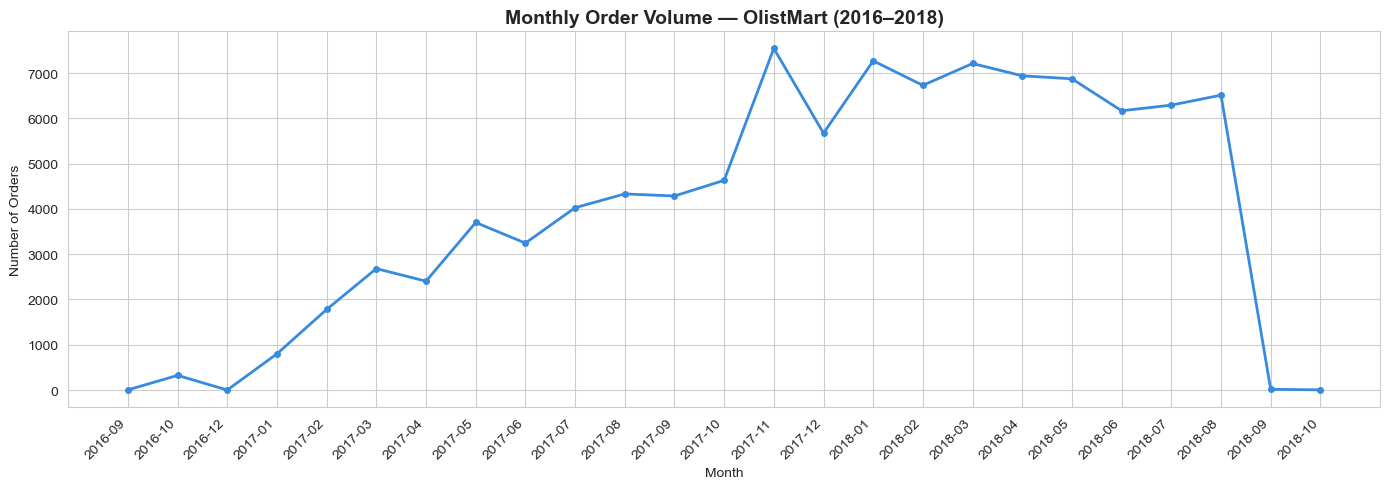

In [15]:
orders['order_month'] = orders['order_purchase_timestamp'].dt.to_period('M')
monthly_orders = orders.groupby('order_month').size().reset_index(name='order_count')

# Convert Period to string for plotting
monthly_orders['order_month'] = monthly_orders['order_month'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly_orders['order_month'], monthly_orders['order_count'],
         marker='o', color='#378ADD', linewidth=2, markersize=4)

plt.title('Monthly Order Volume — OlistMart (2016–2018)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

In [16]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], format='%d-%m-%Y %H:%M')

In [17]:
print("PRODUCTS TABLE")
print(products.head(3))

print("\nProduct category distribution (Top 15):")
print(products['product_category_name'].value_counts().head(15))

print(f"\nTotal unique categories: {products['product_category_name'].nunique()}")

print(f"\nProducts with no category name: {products['product_category_name'].isnull().sum()}")

PRODUCTS TABLE
                         product_id product_category_name  \
0  1e9e8ef04dbcff4541ed26657ea517e5            perfumaria   
1  3aa071139cb16b67ca9e5dea641aaa2f                 artes   
2  96bd76ec8810374ed1b65e291975717f         esporte_lazer   

   product_name_lenght  product_description_lenght  product_photos_qty  \
0                 40.0                       287.0                 1.0   
1                 44.0                       276.0                 1.0   
2                 46.0                       250.0                 1.0   

   product_weight_g  product_length_cm  product_height_cm  product_width_cm  
0             225.0               16.0               10.0              14.0  
1            1000.0               30.0               18.0              20.0  
2             154.0               18.0                9.0              15.0  

Product category distribution (Top 15):
product_category_name
cama_mesa_banho                3029
esporte_lazer                  2

In [18]:
products_en = products.merge(
    category,                             
    on='product_category_name',            
    how='left'                           
)
print("Products with English category names:")
print(products_en[['product_id', 'product_category_name',
                    'product_category_name_english']].head(10))

print(f"\nProducts still missing English name: "
      f"{products_en['product_category_name_english'].isnull().sum()}")


Products with English category names:
                         product_id  product_category_name  \
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumaria   
1  3aa071139cb16b67ca9e5dea641aaa2f                  artes   
2  96bd76ec8810374ed1b65e291975717f          esporte_lazer   
3  cef67bcfe19066a932b7673e239eb23d                  bebes   
4  9dc1a7de274444849c219cff195d0b71  utilidades_domesticas   
5  41d3672d4792049fa1779bb35283ed13  instrumentos_musicais   
6  732bd381ad09e530fe0a5f457d81becb             cool_stuff   
7  2548af3e6e77a690cf3eb6368e9ab61e       moveis_decoracao   
8  37cc742be07708b53a98702e77a21a02       eletrodomesticos   
9  8c92109888e8cdf9d66dc7e463025574             brinquedos   

  product_category_name_english  
0                     perfumery  
1                           art  
2                sports_leisure  
3                          baby  
4                    housewares  
5           musical_instruments  
6                    cool_stuff  
7      

In [19]:
#Seller table
print(sellers.head(3))
print(sellers['seller_state'].value_counts().head(10))

                          seller_id  seller_zip_code_prefix     seller_city  \
0  3442f8959a84dea7ee197c632cb2df15                   13023        campinas   
1  d1b65fc7debc3361ea86b5f14c68d2e2                   13844      mogi guacu   
2  ce3ad9de960102d0677a81f5d0bb7b2d                   20031  rio de janeiro   

  seller_state  
0           SP  
1           SP  
2           RJ  
seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
Name: count, dtype: int64


In [20]:
print("CUSTOMERS TABLE:")
print(customers.head(3))
print(f"\nTotal unique customers: {customers['customer_unique_id'].nunique()}")

print("\nTop 10 states by number of customers:")
customer_state = customers['customer_state'].value_counts().head(10)
print(customer_state)

CUSTOMERS TABLE:
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  

Total unique customers: 96096

Top 10 states by number of customers:
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64


In [21]:
print("PAYMENTS TABLE:")
print(payments.head(3))

print("\nPayment type distribution:")
print(payments['payment_type'].value_counts())

print("\nInstallments distribution (how many EMIs customers choose):")
print(payments['payment_installments'].value_counts().sort_index().head(15))

print(f"\nAverage payment value : $ {payments['payment_value'].mean():.2f}")
print(f"Max payment value     : $ {payments['payment_value'].max():.2f}")
print(f"Total revenue (gross) : $ {payments['payment_value'].sum():,.2f}")

PAYMENTS TABLE:
                           order_id  payment_sequential payment_type  \
0  b81ef226f3fe1789b1e8b2acac839d17                   1  credit_card   
1  a9810da82917af2d9aefd1278f1dcfa0                   1  credit_card   
2  25e8ea4e93396b6fa0d3dd708e76c1bd                   1  credit_card   

   payment_installments  payment_value  
0                     8          99.33  
1                     1          24.39  
2                     1          65.71  

Payment type distribution:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

Installments distribution (how many EMIs customers choose):
payment_installments
0         2
1     52546
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
Name: count, dtype: int64

Average payment value : $ 154.10
Max payment value     : $ 13664.08
To

In [22]:
print("REVIEWS TABLE:")
print(reviews.head(3))

print(f"\nTotal reviews: {len(reviews):,}")
print(f"\nReview score distribution:")
score_dist = reviews['review_score'].value_counts().sort_index()
for score, count in score_dist.items():
    pct = count / len(reviews) * 100
    bar = '█' * int(pct / 2)
    print(f"  {score} stars : {bar} {count:,} ({pct:.1f}%)")

avg_score = reviews['review_score'].mean()
print(f"\nOverall average score: {avg_score:.2f} / 5.0")

REVIEWS TABLE:
                          review_id                          order_id  \
0  7bc2406110b926393aa56f80a40eba40  73fc7af87114b39712e6da79b0a377eb   
1  80e641a11e56f04c1ad469d5645fdfde  a548910a1c6147796b98fdf73dbeba33   
2  228ce5500dc1d8e020d8d1322874b6f0  f9e4b658b201a9f2ecdecbb34bed034b   

   review_score review_comment_title review_comment_message  \
0             4                  NaN                    NaN   
1             5                  NaN                    NaN   
2             5                  NaN                    NaN   

  review_creation_date review_answer_timestamp  
0  2018-01-18 00:00:00     2018-01-18 21:46:59  
1  2018-03-10 00:00:00     2018-03-11 03:05:13  
2  2018-02-17 00:00:00     2018-02-18 14:36:24  

Total reviews: 99,224

Review score distribution:
  1 stars : █████ 11,424 (11.5%)
  2 stars : █ 3,151 (3.2%)
  3 stars : ████ 8,179 (8.2%)
  4 stars : █████████ 19,142 (19.3%)
  5 stars : ████████████████████████████ 57,328 (57.8%)

Overall 

In [23]:
master = orders.merge(customers, on='customer_id', how='left')
print(f"After joining customers: {master.shape}")

master = master.merge(order_items, on='order_id', how='left')
print(f"After joining order_items: {master.shape}")

master = master.merge(
    products_en[['product_id', 'product_category_name_english']],
    on='product_id',
    how='left'
)
print(f"After joining products: {master.shape}")

master = master.merge(
    payments[['order_id', 'payment_type', 'payment_installments', 'payment_value']],
    on='order_id',
    how='left'
)
print(f"After joining payments: {master.shape}")

master = master.merge(
    sellers[['seller_id', 'seller_state']],
    on='seller_id',
    how='left'
)
print(f"After joining sellers: {master.shape}")

master = master.merge(
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='left'
)
print(f"\nFINAL master table: {master.shape[0]:,} rows, {master.shape[1]} columns")
print("\nAll columns in master table:")
print(master.columns.tolist())# This is the most important step of Day 2

master = orders.merge(customers, on='customer_id', how='left')
print(f"After joining customers: {master.shape}")

master = master.merge(order_items, on='order_id', how='left')
print(f"After joining order_items: {master.shape}")

master = master.merge(
    products_en[['product_id', 'product_category_name_english']],
    on='product_id',
    how='left'
)
print(f"After joining products: {master.shape}")

master = master.merge(
    payments[['order_id', 'payment_type', 'payment_installments', 'payment_value']],
    on='order_id',
    how='left'
)
print(f"After joining payments: {master.shape}")

master = master.merge(
    sellers[['seller_id', 'seller_state']],
    on='seller_id',
    how='left'
)
print(f"After joining sellers: {master.shape}")

master = master.merge(
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='left'
)
print(f"\nFINAL master table: {master.shape[0]:,} rows, {master.shape[1]} columns")
print("\nAll columns in master table:")
print(master.columns.tolist())

After joining customers: (99441, 13)
After joining order_items: (113425, 19)
After joining products: (113425, 20)
After joining payments: (118434, 23)
After joining sellers: (118434, 24)

FINAL master table: 119,143 rows, 25 columns

All columns in master table:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_month', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name_english', 'payment_type', 'payment_installments', 'payment_value', 'seller_state', 'review_score']
After joining customers: (99441, 13)
After joining order_items: (113425, 19)
After joining products: (113425, 20)
After joining payments: (118434, 23)
After joining sellers: (118434, 24)

FINAL master table: 119,143 rows, 25 column

In [24]:
master['revenue'] = master['price'] + master['freight_value']

master['delivery_days'] = (
    master['order_delivered_customer_date'] -
    master['order_purchase_timestamp']
).dt.days

master['is_late'] = (
    master['order_delivered_customer_date'] >
    master['order_estimated_delivery_date']
).astype(int)

master['order_year']  = master['order_purchase_timestamp'].dt.year
master['order_month'] = master['order_purchase_timestamp'].dt.month
master['order_yearmonth'] = master['order_purchase_timestamp'].dt.to_period('M').astype(str)

print("New columns added:")
print(master[['revenue', 'delivery_days', 'is_late',
              'order_year', 'order_month', 'order_yearmonth']].head())

print(f"\nAverage delivery days : {master['delivery_days'].mean():.1f} days")
print(f"Late delivery rate    : {master['is_late'].mean()*100:.1f}%")

New columns added:
   revenue  delivery_days  is_late  order_year  order_month order_yearmonth
0    38.71            8.0        0        2017           10         2017-10
1    38.71            8.0        0        2017           10         2017-10
2    38.71            8.0        0        2017           10         2017-10
3   141.46           13.0        0        2018            7         2018-07
4   179.12            9.0        0        2018            8         2018-08

Average delivery days : 12.0 days
Late delivery rate    : 7.6%


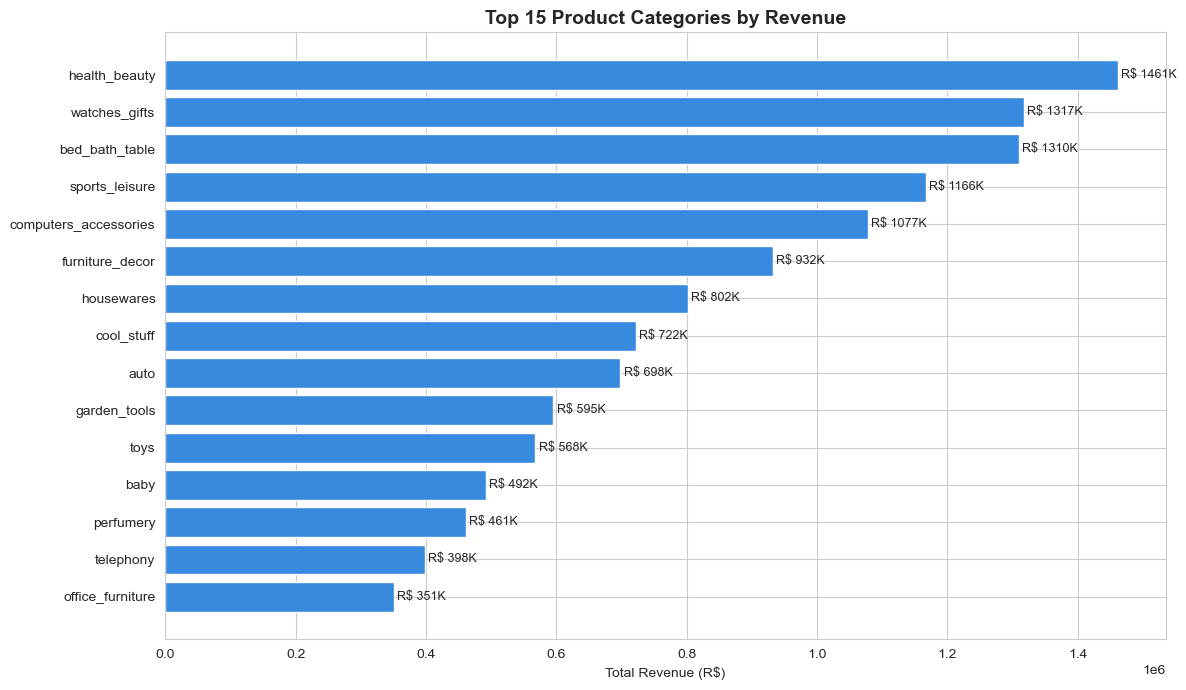

In [25]:

delivered = master[master['order_status'] == 'delivered'].copy()

category_revenue = (
    delivered.groupby('product_category_name_english')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

plt.figure(figsize=(12, 7))
bars = plt.barh(
    category_revenue['product_category_name_english'],
    category_revenue['revenue'],
    color='#378ADD'
)

for bar, val in zip(bars, category_revenue['revenue']):
    plt.text(val + 5000, bar.get_y() + bar.get_height()/2,
             f'R$ {val/1000:.0f}K', va='center', fontsize=9)

plt.xlabel('Total Revenue (R$)')
plt.title('Top 15 Product Categories by Revenue', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  
plt.tight_layout()

plt.show()

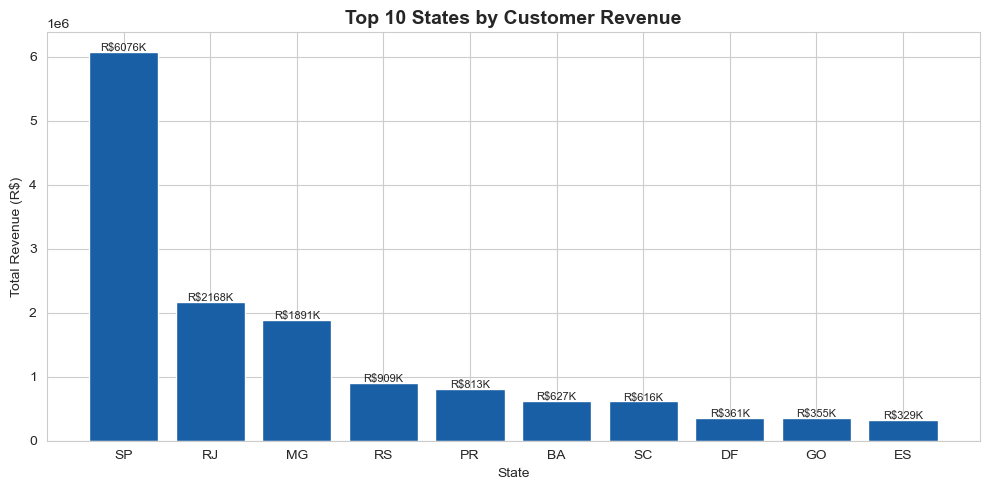

In [26]:
state_revenue = (
    delivered.groupby('customer_state')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 5))
bars = plt.bar(
    state_revenue['customer_state'],
    state_revenue['revenue'],
    color='#185FA5',
    edgecolor='white'
)

for bar, val in zip(bars, state_revenue['revenue']):
    plt.text(bar.get_x() + bar.get_width()/2, val + 10000,
             f'R${val/1000:.0f}K', ha='center', fontsize=8)

plt.title('Top 10 States by Customer Revenue', fontsize=14, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Total Revenue (R$)')
plt.tight_layout()
plt.show()

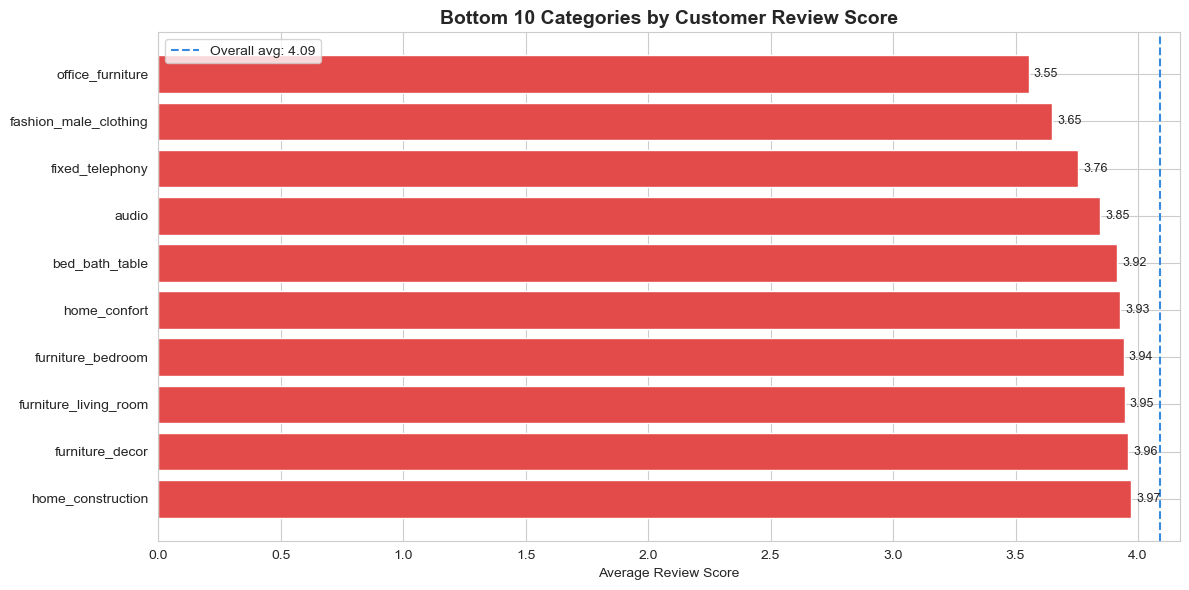

In [27]:

category_reviews = (
    delivered.groupby('product_category_name_english')['review_score']
    .agg(['mean', 'count'])          
    .reset_index()
    .rename(columns={'mean': 'avg_score', 'count': 'review_count'})
)

category_reviews = category_reviews[category_reviews['review_count'] >= 100]

worst_categories = category_reviews.sort_values('avg_score').head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(
    worst_categories['product_category_name_english'],
    worst_categories['avg_score'],
    color='#E24B4A'
)

plt.axvline(x=4.09, color='#378ADD', linestyle='--',
            label=f'Overall avg: 4.09')

for bar, val in zip(bars, worst_categories['avg_score']):
    plt.text(val + 0.02, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=9)

plt.xlabel('Average Review Score')
plt.title('Bottom 10 Categories by Customer Review Score', fontsize=14, fontweight='bold')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

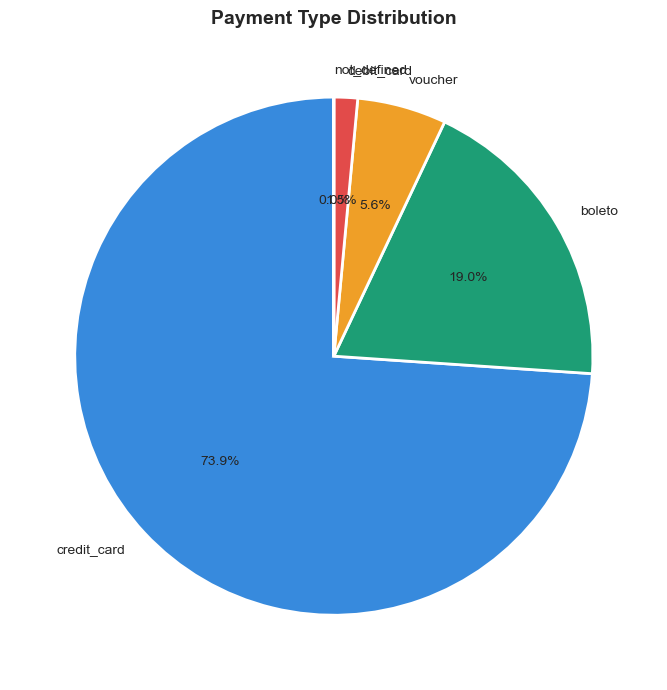

In [28]:
payment_dist = payments['payment_type'].value_counts()

colors = ['#378ADD', '#1D9E75', '#EF9F27', '#E24B4A']

plt.figure(figsize=(7, 7))
wedges, texts, autotexts = plt.pie(
    payment_dist.values,
    labels=payment_dist.index,
    autopct='%1.1f%%',        
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
plt.title('Payment Type Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()

In [29]:
output_path = r"D:\Data Analytics\Data Analyst Project\E-Commerce Sales & Customer Analytics Dashboard\Dataset"
master.to_csv(os.path.join(output_path, "master_raw.csv"), index=False)


print(f"Master table saved: {master.shape[0]:,} rows, {master.shape[1]} columns")


Master table saved: 119,143 rows, 30 columns


In [30]:
print(master.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_month', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name_english', 'payment_type', 'payment_installments', 'payment_value', 'seller_state', 'review_score', 'revenue', 'delivery_days', 'is_late', 'order_year', 'order_yearmonth']


In [31]:

date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
    ]

for col in date_cols:
    master[col] = pd.to_datetime(master[col], errors='coerce')

print("Date columns converted:")
for col in date_cols:
    print(f"  {col} — dtype: {master[col].dtype}")

Date columns converted:
  order_purchase_timestamp — dtype: datetime64[ns]
  order_approved_at — dtype: datetime64[ns]
  order_delivered_carrier_date — dtype: datetime64[ns]
  order_delivered_customer_date — dtype: datetime64[ns]
  order_estimated_delivery_date — dtype: datetime64[ns]


In [32]:

print("=" * 60)
print("NULL VALUE AUDIT — BEFORE CLEANING")
print("=" * 60)

null_report = pd.DataFrame({
    'Null Count'  : master.isnull().sum(),
    'Null Percent': (master.isnull().sum() / len(master) * 100).round(2),
    'Data Type'   : master.dtypes
})

null_report = null_report[null_report['Null Count'] > 0]
print(null_report.to_string())

print(f"\nTotal cells with nulls: {master.isnull().sum().sum():,}")
print(f"Total cells in dataset: {master.size:,}")
print(f"Overall null rate     : {master.isnull().sum().sum()/master.size*100:.2f}%")

NULL VALUE AUDIT — BEFORE CLEANING
                               Null Count  Null Percent       Data Type
order_approved_at                     177          0.15  datetime64[ns]
order_delivered_carrier_date         2086          1.75  datetime64[ns]
order_delivered_customer_date        3421          2.87  datetime64[ns]
order_item_id                         833          0.70         float64
product_id                            833          0.70          object
seller_id                             833          0.70          object
shipping_limit_date                   833          0.70          object
price                                 833          0.70         float64
freight_value                         833          0.70         float64
product_category_name_english        2567          2.15          object
payment_type                            3          0.00          object
payment_installments                    3          0.00         float64
payment_value                

In [34]:
print("Order status before filtering:")
print(master['order_status'].value_counts())
print(f"Total rows before: {len(master):,}")

master_clean = master[master['order_status'] == 'delivered'].copy()

print(f"\nTotal rows after keeping delivered only: {len(master_clean):,}")
print(f"Rows removed (non-delivered): {len(master) - len(master_clean):,}")
print(len(master))
print(len(master_clean))

Order status before filtering:
order_status
delivered      115723
shipped          1256
canceled          750
unavailable       652
invoiced          378
processing        376
created             5
approved            3
Name: count, dtype: int64
Total rows before: 119,143

Total rows after keeping delivered only: 115,723
Rows removed (non-delivered): 3,420
119143
115723


In [35]:
before = len(master_clean)

master_clean = master_clean.dropna(
    subset=['order_delivered_customer_date']
)
after = len(master_clean)
print(f"Rows removed due to missing delivery date: {before - after:,}")
print(f"Rows remaining: {after:,}")

Rows removed due to missing delivery date: 8
Rows remaining: 115,715


In [36]:
print(f"Missing category names before: "
      f"{master_clean['product_category_name_english'].isnull().sum():,}")

master_clean['product_category_name_english'] = (
    master_clean['product_category_name_english']
    .fillna('unknown')
)

print(f"Missing category names after : "
      f"{master_clean['product_category_name_english'].isnull().sum():,}")

Missing category names before: 1,661
Missing category names after : 0


In [37]:
median_score = master_clean['review_score'].median()
print(f"Median review score: {median_score}")

print(f"Missing review scores before: "
      f"{master_clean['review_score'].isnull().sum():,}")

master_clean['review_score'] = (
    master_clean['review_score']
    .fillna(median_score)
)

print(f"Missing review scores after : "
      f"{master_clean['review_score'].isnull().sum():,}")


Median review score: 5.0
Missing review scores before: 861
Missing review scores after : 0


In [38]:
before = len(master_clean)

master_clean = master_clean.dropna(subset=['payment_value'])

after = len(master_clean)
print(f"Rows removed due to missing payment value: {before - after:,}")
print(f"Rows remaining: {after:,}")

Rows removed due to missing payment value: 3
Rows remaining: 115,712


In [39]:
before = len(master_clean)

master_clean = master_clean.drop_duplicates()

after = len(master_clean)
print(f"Duplicate rows removed: {before - after:,}")
print(f"Rows remaining: {after:,}")

Duplicate rows removed: 1,082
Rows remaining: 114,630


In [40]:
print("Price column stats BEFORE cleaning:")
print(master_clean['price'].describe())

before = len(master_clean)
master_clean = master_clean[master_clean['price'] > 0]
master_clean = master_clean[master_clean['freight_value'] >= 0]
after = len(master_clean)

print(f"\nRows removed due to zero/negative price: {before - after:,}")

print("\nPrice column stats AFTER cleaning:")
print(master_clean['price'].describe())

Price column stats BEFORE cleaning:
count    114630.000000
mean        119.988423
std         182.863330
min           0.850000
25%          39.900000
50%          74.900000
75%         133.000000
max        6735.000000
Name: price, dtype: float64

Rows removed due to zero/negative price: 0

Price column stats AFTER cleaning:
count    114630.000000
mean        119.988423
std         182.863330
min           0.850000
25%          39.900000
50%          74.900000
75%         133.000000
max        6735.000000
Name: price, dtype: float64


In [41]:
master_clean['revenue'] = master_clean['price'] + master_clean['freight_value']

master_clean['delivery_days'] = (
    master_clean['order_delivered_customer_date'] -
    master_clean['order_purchase_timestamp']
).dt.days


master_clean['is_late'] = (
    master_clean['order_delivered_customer_date'] >
    master_clean['order_estimated_delivery_date']
).astype(int)

master_clean['order_year']      = master_clean['order_purchase_timestamp'].dt.year
master_clean['order_month']     = master_clean['order_purchase_timestamp'].dt.month
master_clean['order_quarter']   = master_clean['order_purchase_timestamp'].dt.quarter
master_clean['order_yearmonth'] = (
    master_clean['order_purchase_timestamp']
    .dt.to_period('M')
    .astype(str)
)
master_clean['order_dayofweek'] = master_clean['order_purchase_timestamp'].dt.day_name()

print("Derived columns recalculated:")
print(master_clean[['revenue', 'delivery_days', 'is_late',
                     'order_year', 'order_month',
                     'order_quarter', 'order_yearmonth',
                     'order_dayofweek']].head(5))

Derived columns recalculated:
   revenue  delivery_days  is_late  order_year  order_month  order_quarter  \
0    38.71              8        0        2017           10              4   
1    38.71              8        0        2017           10              4   
2    38.71              8        0        2017           10              4   
3   141.46             13        0        2018            7              3   
4   179.12              9        0        2018            8              3   

  order_yearmonth order_dayofweek  
0         2017-10          Monday  
1         2017-10          Monday  
2         2017-10          Monday  
3         2018-07         Tuesday  
4         2018-08       Wednesday  


In [42]:
master_clean['customer_state'] = master_clean['customer_state'].str.strip().str.upper()
master_clean['seller_state']   = master_clean['seller_state'].str.strip().str.upper()
master_clean['payment_type']   = master_clean['payment_type'].str.strip().str.lower()

print("Sample values after standardising:")
print("Customer states:", master_clean['customer_state'].unique()[:8])
print("Payment types :", master_clean['payment_type'].unique())

Sample values after standardising:
Customer states: ['SP' 'BA' 'GO' 'RN' 'PR' 'RJ' 'RS' 'MG']
Payment types : ['credit_card' 'voucher' 'boleto' 'debit_card']


In [43]:
print("=" * 60)
print("NULL VALUE AUDIT — AFTER CLEANING")
print("=" * 60)

important_cols = [
    'order_id', 'customer_unique_id', 'order_status',
    'order_purchase_timestamp', 'order_delivered_customer_date',
    'product_category_name_english', 'price', 'freight_value',
    'revenue', 'delivery_days', 'review_score',
    'customer_state', 'payment_type', 'payment_value'
]

final_null = master_clean[important_cols].isnull().sum()
print(final_null)

if final_null.sum() == 0:
    print("\n✓ All important columns are clean — zero nulls!")
else:
    print("\n⚠ Some nulls remain — check above columns")

NULL VALUE AUDIT — AFTER CLEANING
order_id                         0
customer_unique_id               0
order_status                     0
order_purchase_timestamp         0
order_delivered_customer_date    0
product_category_name_english    0
price                            0
freight_value                    0
revenue                          0
delivery_days                    0
review_score                     0
customer_state                   0
payment_type                     0
payment_value                    0
dtype: int64

✓ All important columns are clean — zero nulls!


In [44]:
print("=" * 60)
print("DATA CLEANING SUMMARY REPORT")
print("=" * 60)
print(f"Original rows (master_raw)     : {len(master):,}")
print(f"Final rows (master_clean)      : {len(master_clean):,}")
print(f"Rows removed total             : {len(master) - len(master_clean):,}")
print()
print("Actions taken:")
print("  1. Kept only delivered orders — removed cancelled/unavailable")
print("  2. Dropped rows with missing delivery date")
print("  3. Filled missing category names with 'unknown'")
print("  4. Filled missing review scores with median score")
print("  5. Dropped rows with missing payment value")
print("  6. Removed duplicate rows")
print("  7. Removed rows with zero or negative price")
print("  8. Recalculated revenue, delivery_days, is_late on clean data")
print("  9. Standardised state codes and payment type text")
print()
print(f"Final dataset ready for SQL and Power BI")
print(f"Columns in clean dataset: {master_clean.shape[1]}")

DATA CLEANING SUMMARY REPORT
Original rows (master_raw)     : 119,143
Final rows (master_clean)      : 114,630
Rows removed total             : 4,513

Actions taken:
  1. Kept only delivered orders — removed cancelled/unavailable
  2. Dropped rows with missing delivery date
  3. Filled missing category names with 'unknown'
  4. Filled missing review scores with median score
  5. Dropped rows with missing payment value
  6. Removed duplicate rows
  7. Removed rows with zero or negative price
  8. Recalculated revenue, delivery_days, is_late on clean data
  9. Standardised state codes and payment type text

Final dataset ready for SQL and Power BI
Columns in clean dataset: 32


In [46]:
clean_path = os.path.join(DATA_PATH, "master_clean.csv")
master_clean.to_csv(clean_path, index=False)

print(f"master_clean.csv saved successfully!")
print(f"Location: {clean_path}")
print(f"Size: {master_clean.shape[0]:,} rows x {master_clean.shape[1]} columns")

summary = pd.DataFrame({
    'Metric'  : ['Total Orders', 'Total Revenue (R$)', 'Unique Customers',
                 'Unique Products', 'Avg Delivery Days', 'Late Delivery %',
                 'Avg Review Score', 'Date Range Start', 'Date Range End'],
    'Value'   : [
        master_clean['order_id'].nunique(),
        round(master_clean['revenue'].sum(), 2),
        master_clean['customer_unique_id'].nunique(),
        master_clean['product_id'].nunique(),
        round(master_clean['delivery_days'].mean(), 1),
        f"{master_clean['is_late'].mean()*100:.1f}%",
        round(master_clean['review_score'].mean(), 2),
        master_clean['order_purchase_timestamp'].min().strftime('%Y-%m-%d'),
        master_clean['order_purchase_timestamp'].max().strftime('%Y-%m-%d')
    ]
})
OUTPUT_PATH = r"D:\Data Analytics\Data Analyst Project\E-Commerce Sales & Customer Analytics Dashboard\Dataset"
excel_path = os.path.join(OUTPUT_PATH, "dataset_summary.xlsx")
summary.to_excel(excel_path, index=False)
print(f"\nSummary Excel saved: {excel_path}")

master_clean.csv saved successfully!
Location: D:\Data Analytics\Data Analyst Project\E-Commerce Sales & Customer Analytics Dashboard\Dataset\master_clean.csv
Size: 114,630 rows x 32 columns

Summary Excel saved: D:\Data Analytics\Data Analyst Project\E-Commerce Sales & Customer Analytics Dashboard\Dataset\dataset_summary.xlsx
